# Análise do Yelp dataset

## CDF da quantidade de amigos

Apenas para usuários com algum amigo

Número de usuários considerados: 1,109,346

Percentis de friend_count:
P50: 35 amigos
P75: 114 amigos
P90: 250 amigos
P95: 373 amigos
P99: 748 amigos


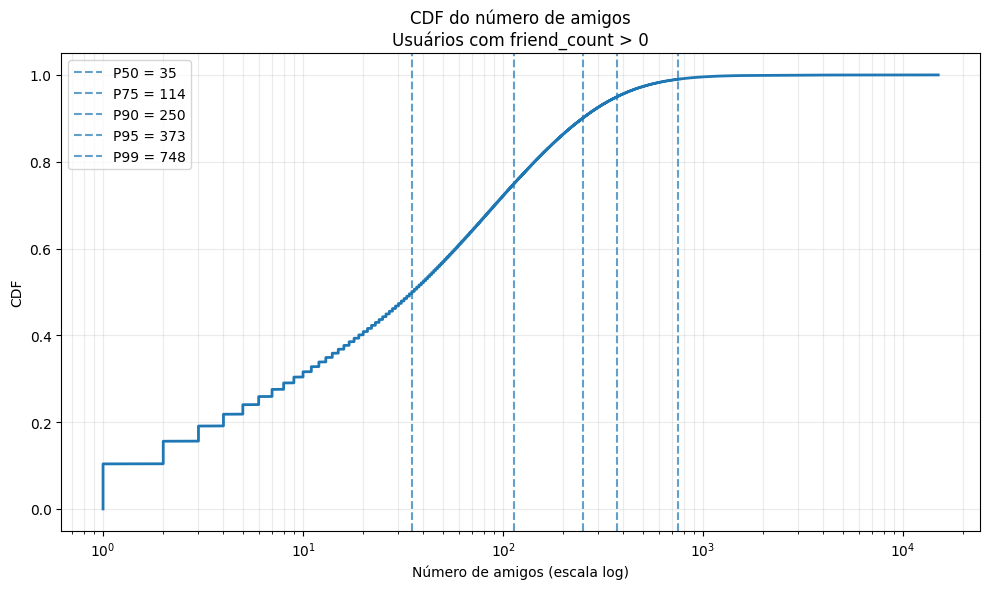

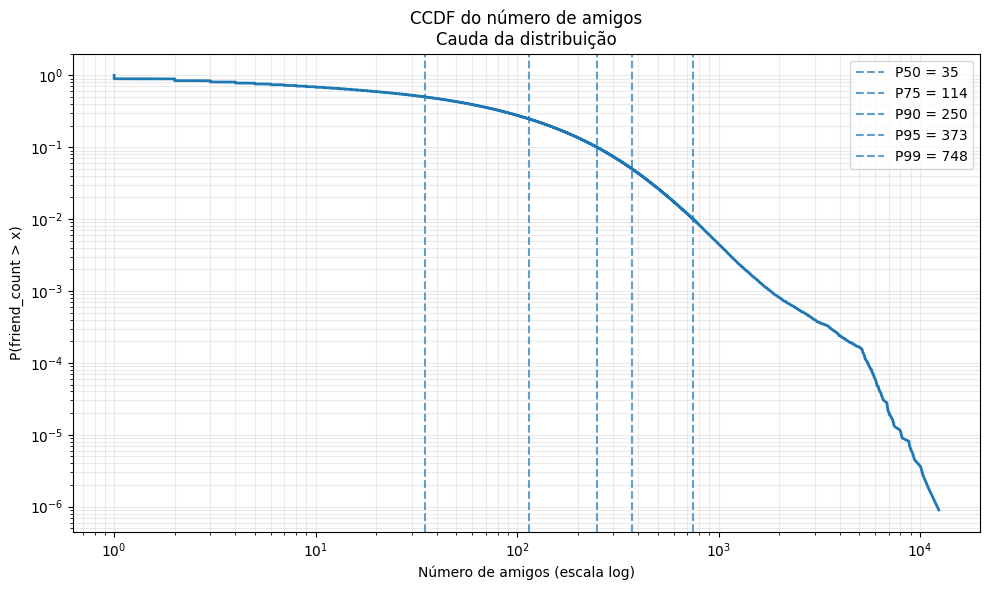

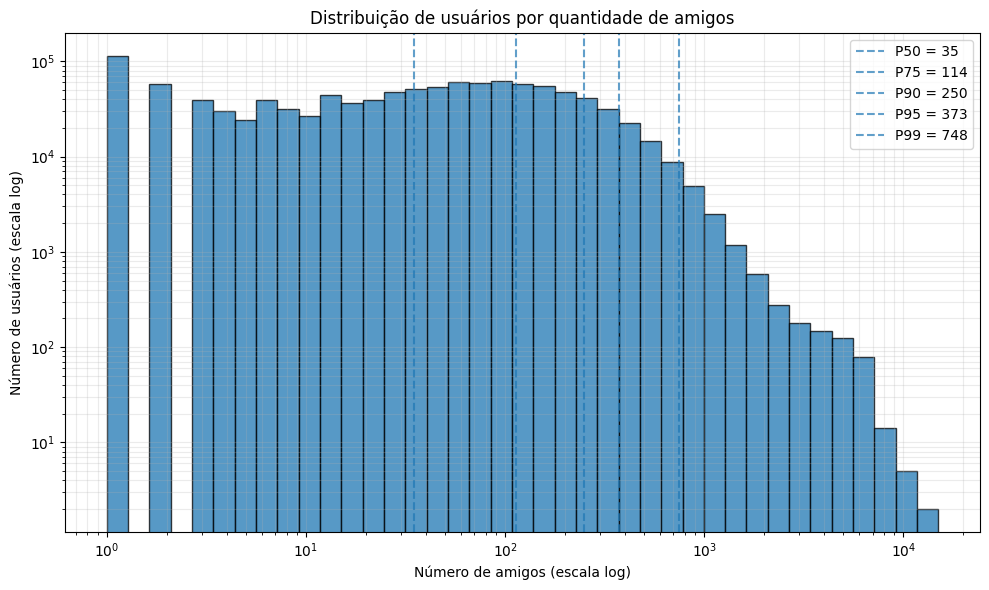

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# 1. Leitura dos dados
# ============================================================

arquivo = "/home/miguel/Documents/UFES/TCC/recsys_fairness/data/processed/yelp/yelp.user"

df = pd.read_csv(arquivo, sep="\t")

friend_count = pd.to_numeric(
    df["friend_count:float"],
    errors="coerce"
)

# Remove valores inválidos e usuários sem amigos
friend_count = friend_count[
    friend_count.notna() & (friend_count > 0)
].to_numpy()


# ============================================================
# 2. Estatísticas / pontos de corte
# ============================================================

percentis = [50, 75, 90, 95, 99]

limites = np.percentile(friend_count, percentis)

print(f"Número de usuários considerados: {len(friend_count):,}")
print()

print("Percentis de friend_count:")

for p, valor in zip(percentis, limites):
    print(f"P{p}: {valor:.0f} amigos")


# ============================================================
# 3. CDF
# ============================================================

x = np.sort(friend_count)

cdf = np.arange(1, len(x) + 1) / len(x)


plt.figure(figsize=(10, 6))

plt.plot(
    x,
    cdf,
    linewidth=2
)

# Escala logarítmica é importante aqui
plt.xscale("log")

# Linhas verticais nos percentis
for p, valor in zip(percentis, limites):

    plt.axvline(
        valor,
        linestyle="--",
        alpha=0.7,
        label=f"P{p} = {valor:.0f}"
    )


plt.xlabel("Número de amigos (escala log)")
plt.ylabel("CDF")

plt.title(
    "CDF do número de amigos\n"
    "Usuários com friend_count > 0"
)

plt.grid(
    True,
    which="both",
    alpha=0.25
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 4. CCDF
# ============================================================
#
# A CCDF responde:
#
#   "Qual fração dos usuários possui MAIS de X amigos?"
#
# Ela costuma ser mais útil do que a CDF para analisar
# distribuições com cauda longa.
# ============================================================

ccdf = 1 - cdf

# O último ponto da CCDF é zero.
# Não podemos mostrar zero em escala log.
mask = ccdf > 0


plt.figure(figsize=(10, 6))

plt.plot(
    x[mask],
    ccdf[mask],
    linewidth=2
)

plt.xscale("log")
plt.yscale("log")


for p, valor in zip(percentis, limites):

    plt.axvline(
        valor,
        linestyle="--",
        alpha=0.7,
        label=f"P{p} = {valor:.0f}"
    )


plt.xlabel("Número de amigos (escala log)")
plt.ylabel("P(friend_count > x)")

plt.title(
    "CCDF do número de amigos\n"
    "Cauda da distribuição"
)

plt.grid(
    True,
    which="both",
    alpha=0.25
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 5. Histograma com bins logarítmicos
# ============================================================
#
# Esse gráfico é particularmente interessante para tentar
# identificar possíveis grupos de usuários.
# ============================================================

min_amigos = friend_count.min()
max_amigos = friend_count.max()

bins = np.logspace(
    np.log10(min_amigos),
    np.log10(max_amigos),
    40
)


plt.figure(figsize=(10, 6))

plt.hist(
    friend_count,
    bins=bins,
    edgecolor="black",
    alpha=0.75
)

plt.xscale("log")
plt.yscale("log")


for p, valor in zip(percentis, limites):

    plt.axvline(
        valor,
        linestyle="--",
        alpha=0.7,
        label=f"P{p} = {valor:.0f}"
    )


plt.xlabel("Número de amigos (escala log)")
plt.ylabel("Número de usuários (escala log)")

plt.title(
    "Distribuição de usuários por quantidade de amigos"
)

plt.grid(
    True,
    which="both",
    alpha=0.25
)

plt.legend()

plt.tight_layout()
plt.show()

## Análise de densidade da matriz

Loading interactions...
Rows read:                 6,745,727
Unique user-item pairs:    6,745,727
Duplicate pairs removed:   0

Initial matrix
------------------------------------------------------------
Users:         1,987,897
Items:         150,346
Interactions:  6,745,727
Possible cells:298,872,362,362
Density:       0.002257%


GREEDY SEARCH RESULTS
Iterations performed: 2,123,243
Maximum density found: 0.801184%

The requested density of 36.00% was NOT reached.

Consider decreasing MIN_USERS / MIN_ITEMS if you want the algorithm to continue reducing the matrix.

CSV files generated:
  - density_greedy_history.csv
  - density_target_combinations.csv


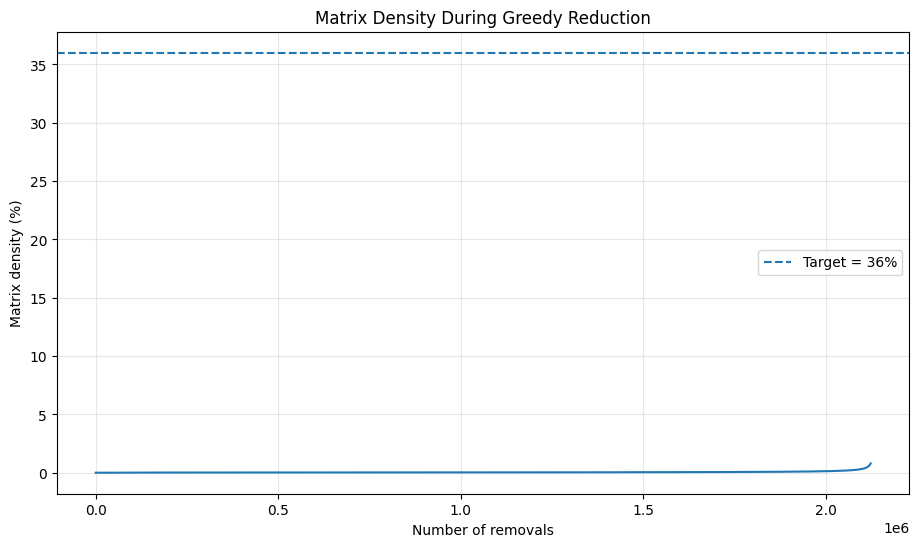

/home/miguel/Documents/UFES/TCC/recsys_fairness/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


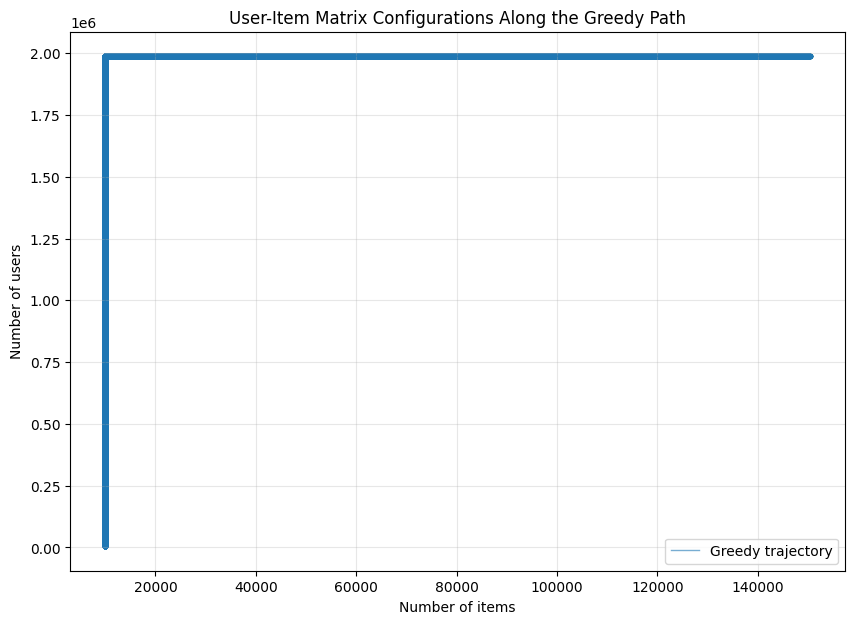

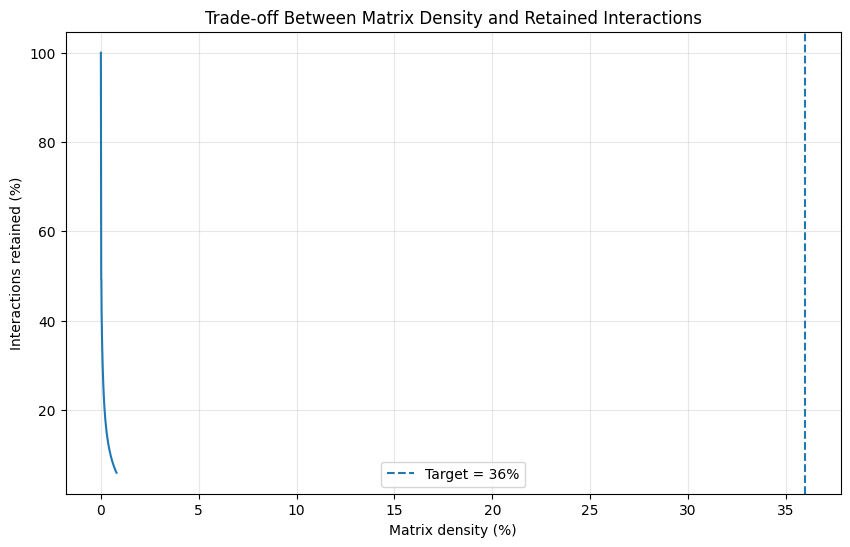

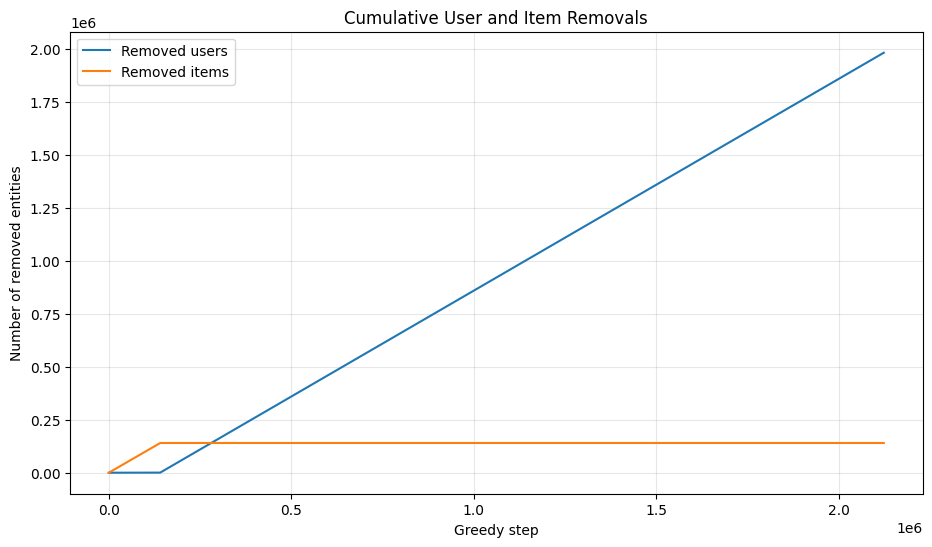



SUGGESTED CONFIGURATION
Users:                    5,000
Items:                    10,000
Interactions:             400,592
Possible matrix cells:    50,000,000
Density:                  0.801184%
Users retained:           0.25%
Items retained:           6.65%
Interactions retained:    5.94%
----------------------------------------------------------------------
✗ The final matrix does NOT satisfy the target density of 36.00%.
  Achieved density: 0.801184%
  Difference from target: 35.198816%

The matrix cannot be reduced further because the minimum constraints are 5,000 users and 10,000 items.


In [6]:
# ============================================================
# Greedy User-Item Matrix Density Analysis
# ============================================================
#
# Strategy:
#   1. Start with the complete interaction matrix.
#   2. At each iteration:
#       a) find the least active user;
#       b) find the least popular item;
#       c) calculate the density obtained by removing each one;
#       d) perform whichever removal produces the highest density.
#   3. Update the degrees dynamically.
#   4. Record every (number of users, number of items) combination.
#   5. Report all combinations with density >= TARGET_DENSITY.
#
# Density:
#
#       number of observed user-item interactions
#   ------------------------------------------------
#          number of users * number of items
#
# ============================================================

import heapq

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import sparse

# ============================================================
# 1. CONFIGURATION
# ============================================================

FILE_PATH = "/home/miguel/Documents/UFES/TCC/recsys_fairness/data/processed/yelp/yelp.inter"

USER_COL = "user_id:token"
ITEM_COL = "item_id:token"

# Desired matrix density
TARGET_DENSITY = 0.36

# Minimum matrix dimensions allowed during the search.
#
# Change these if very small matrices would not be useful
# for your experiment.
#
# Examples:
#   MIN_USERS = 300
#   MIN_ITEMS = 1000
#
# Using 2 allows the algorithm to explore almost the
# complete greedy trajectory.
MIN_USERS = 5_000
MIN_ITEMS = 10_000

# Optional limit for testing.
# None = execute the complete trajectory.
MAX_STEPS = None

# Save results as CSV files
SAVE_RESULTS = True


# ============================================================
# 2. LOAD DATA
# ============================================================

print("Loading interactions...")

df = pd.read_csv(
    FILE_PATH,
    sep="\t",
    usecols=[USER_COL, ITEM_COL]
)

original_rows = len(df)

# Density concerns occupied user-item cells.
# Therefore, duplicate user-item pairs must count only once.
pairs = df.drop_duplicates(
    subset=[USER_COL, ITEM_COL]
).copy()

unique_interactions = len(pairs)
duplicates_removed = original_rows - unique_interactions

print(f"Rows read:                 {original_rows:,}")
print(f"Unique user-item pairs:    {unique_interactions:,}")
print(f"Duplicate pairs removed:   {duplicates_removed:,}")


# ============================================================
# 3. CONVERT IDS TO INTEGER INDICES
# ============================================================

user_codes, user_ids = pd.factorize(
    pairs[USER_COL],
    sort=False
)

item_codes, item_ids = pd.factorize(
    pairs[ITEM_COL],
    sort=False
)

n_users_initial = len(user_ids)
n_items_initial = len(item_ids)
n_interactions_initial = len(pairs)


# ============================================================
# 4. CREATE SPARSE USER-ITEM MATRIX
# ============================================================

# CSR is efficient for retrieving the items of a user.
csr = sparse.csr_matrix(
    (
        np.ones(n_interactions_initial, dtype=np.uint8),
        (user_codes, item_codes)
    ),
    shape=(n_users_initial, n_items_initial)
)

# CSC is efficient for retrieving the users of an item.
csc = csr.tocsc()


# Initial degrees
user_degree = np.diff(csr.indptr).astype(np.int64)
item_degree = np.diff(csc.indptr).astype(np.int64)

active_users = np.ones(n_users_initial, dtype=bool)
active_items = np.ones(n_items_initial, dtype=bool)


# ============================================================
# 5. INITIAL MATRIX STATISTICS
# ============================================================

initial_density = (
    n_interactions_initial
    / (n_users_initial * n_items_initial)
)

print("\nInitial matrix")
print("-" * 60)
print(f"Users:         {n_users_initial:,}")
print(f"Items:         {n_items_initial:,}")
print(f"Interactions:  {n_interactions_initial:,}")
print(f"Possible cells:{n_users_initial * n_items_initial:,}")
print(f"Density:       {initial_density:.6%}")


# ============================================================
# 6. MIN-HEAPS
# ============================================================
#
# These allow us to retrieve the current lowest-degree
# user/item efficiently.
#
# When a degree changes, a new entry is inserted.
# Outdated entries are removed lazily.
# ============================================================

user_heap = [
    (int(user_degree[u]), u)
    for u in range(n_users_initial)
]

item_heap = [
    (int(item_degree[i]), i)
    for i in range(n_items_initial)
]

heapq.heapify(user_heap)
heapq.heapify(item_heap)


def get_current_min(heap, degrees, active):
    """
    Return the currently active entity with minimum degree.

    Old heap entries are discarded lazily.
    """

    while heap:

        degree, idx = heap[0]

        if (
            not active[idx]
            or degree != degrees[idx]
        ):
            heapq.heappop(heap)
            continue

        return int(degree), int(idx)

    return None, None


# ============================================================
# 7. GREEDY DENSITY SEARCH
# ============================================================

current_users = n_users_initial
current_items = n_items_initial
current_interactions = n_interactions_initial

history = []

# Initial state
history.append({
    "step": 0,
    "n_users": current_users,
    "n_items": current_items,
    "n_interactions": current_interactions,
    "density": initial_density,

    "removed_type": None,
    "removed_id": None,
    "removed_degree": None,

    "density_if_remove_user": np.nan,
    "density_if_remove_item": np.nan
})


step = 0


while True:

    # --------------------------------------------------------
    # Stop conditions
    # --------------------------------------------------------

    can_remove_user = current_users > MIN_USERS
    can_remove_item = current_items > MIN_ITEMS

    if not can_remove_user and not can_remove_item:
        break

    if MAX_STEPS is not None and step >= MAX_STEPS:
        break


    # --------------------------------------------------------
    # Lowest-degree candidates
    # --------------------------------------------------------

    min_user_degree = None
    min_user_idx = None

    min_item_degree = None
    min_item_idx = None


    if can_remove_user:
        min_user_degree, min_user_idx = get_current_min(
            user_heap,
            user_degree,
            active_users
        )


    if can_remove_item:
        min_item_degree, min_item_idx = get_current_min(
            item_heap,
            item_degree,
            active_items
        )


    # --------------------------------------------------------
    # Simulate user removal
    # --------------------------------------------------------

    if can_remove_user:

        density_remove_user = (
            (current_interactions - min_user_degree)
            /
            ((current_users - 1) * current_items)
        )

    else:
        density_remove_user = -np.inf


    # --------------------------------------------------------
    # Simulate item removal
    # --------------------------------------------------------

    if can_remove_item:

        density_remove_item = (
            (current_interactions - min_item_degree)
            /
            (current_users * (current_items - 1))
        )

    else:
        density_remove_item = -np.inf


    # --------------------------------------------------------
    # Decide which entity to remove
    # --------------------------------------------------------
    #
    # Primary criterion:
    #     choose the removal producing the largest density.
    #
    # Tie-breaking:
    #     remove from the currently larger dimension.
    #
    # --------------------------------------------------------

    tolerance = 1e-15

    if density_remove_user > density_remove_item + tolerance:

        choice = "user"

    elif density_remove_item > density_remove_user + tolerance:

        choice = "item"

    else:

        if can_remove_user and can_remove_item:

            if current_users >= current_items:
                choice = "user"
            else:
                choice = "item"

        elif can_remove_user:
            choice = "user"

        else:
            choice = "item"


    # ========================================================
    # REMOVE USER
    # ========================================================

    if choice == "user":

        u = min_user_idx
        degree_removed = int(user_degree[u])

        removed_id = str(user_ids[u])

        # Number of interactions decreases by the current
        # number of active items connected to this user.
        current_interactions -= degree_removed

        active_users[u] = False
        current_users -= 1


        # Update degrees of neighboring items
        start = csr.indptr[u]
        end = csr.indptr[u + 1]

        for pos in range(start, end):

            item = csr.indices[pos]

            if active_items[item]:

                item_degree[item] -= 1

                heapq.heappush(
                    item_heap,
                    (int(item_degree[item]), int(item))
                )


    # ========================================================
    # REMOVE ITEM
    # ========================================================

    else:

        i = min_item_idx
        degree_removed = int(item_degree[i])

        removed_id = str(item_ids[i])

        current_interactions -= degree_removed

        active_items[i] = False
        current_items -= 1


        # Update degrees of neighboring users
        start = csc.indptr[i]
        end = csc.indptr[i + 1]

        for pos in range(start, end):

            user = csc.indices[pos]

            if active_users[user]:

                user_degree[user] -= 1

                heapq.heappush(
                    user_heap,
                    (int(user_degree[user]), int(user))
                )


    # --------------------------------------------------------
    # New density
    # --------------------------------------------------------

    current_density = (
        current_interactions
        /
        (current_users * current_items)
    )


    step += 1


    history.append({
        "step": step,

        "n_users": current_users,
        "n_items": current_items,
        "n_interactions": current_interactions,

        "density": current_density,

        "removed_type": choice,
        "removed_id": removed_id,
        "removed_degree": degree_removed,

        "density_if_remove_user": (
            density_remove_user
            if np.isfinite(density_remove_user)
            else np.nan
        ),

        "density_if_remove_item": (
            density_remove_item
            if np.isfinite(density_remove_item)
            else np.nan
        )
    })


# ============================================================
# 8. RESULTS DATAFRAME
# ============================================================

history_df = pd.DataFrame(history)

history_df["density_percent"] = (
    history_df["density"] * 100
)

history_df["users_retained_percent"] = (
    history_df["n_users"]
    / n_users_initial
    * 100
)

history_df["items_retained_percent"] = (
    history_df["n_items"]
    / n_items_initial
    * 100
)

history_df["interactions_retained_percent"] = (
    history_df["n_interactions"]
    / n_interactions_initial
    * 100
)

history_df["matrix_cells"] = (
    history_df["n_users"]
    * history_df["n_items"]
)

history_df["matrix_cells_retained_percent"] = (
    history_df["matrix_cells"]
    /
    (n_users_initial * n_items_initial)
    * 100
)


# ============================================================
# 9. COMBINATIONS THAT REACH THE TARGET DENSITY
# ============================================================

target_df = history_df[
    history_df["density"] >= TARGET_DENSITY
].copy()


print("\n")
print("=" * 70)
print("GREEDY SEARCH RESULTS")
print("=" * 70)

print(f"Iterations performed: {len(history_df) - 1:,}")
print(
    f"Maximum density found: "
    f"{history_df['density'].max():.6%}"
)


if len(target_df) == 0:

    print(
        f"\nThe requested density of "
        f"{TARGET_DENSITY:.2%} was NOT reached."
    )

    print(
        "\nConsider decreasing MIN_USERS / MIN_ITEMS "
        "if you want the algorithm to continue reducing "
        "the matrix."
    )

else:

    # Since density does not decrease under this greedy
    # elimination, this is the first / largest matrix
    # reaching the requested target.
    first_target = target_df.iloc[0]

    print(
        f"\nTarget density reached: "
        f"{TARGET_DENSITY:.2%}"
    )

    print("\nFIRST COMBINATION REACHING THE TARGET")
    print("-" * 70)

    print(
        f"Step:                     "
        f"{int(first_target['step']):,}"
    )

    print(
        f"Users:                    "
        f"{int(first_target['n_users']):,}"
    )

    print(
        f"Items:                    "
        f"{int(first_target['n_items']):,}"
    )

    print(
        f"Interactions:             "
        f"{int(first_target['n_interactions']):,}"
    )

    print(
        f"Density:                  "
        f"{first_target['density']:.6%}"
    )

    print(
        f"Users retained:           "
        f"{first_target['users_retained_percent']:.2f}%"
    )

    print(
        f"Items retained:           "
        f"{first_target['items_retained_percent']:.2f}%"
    )

    print(
        f"Interactions retained:    "
        f"{first_target['interactions_retained_percent']:.2f}%"
    )

    print(
        f"Matrix cells retained:    "
        f"{first_target['matrix_cells_retained_percent']:.2f}%"
    )


    # --------------------------------------------------------
    # Show combinations around the threshold
    # --------------------------------------------------------

    first_target_step = int(first_target["step"])

    lower_step = max(0, first_target_step - 5)
    upper_step = min(
        len(history_df),
        first_target_step + 6
    )

    around_target = history_df.iloc[
        lower_step:upper_step
    ][[
        "step",
        "n_users",
        "n_items",
        "n_interactions",
        "density_percent",
        "interactions_retained_percent",
        "removed_type"
    ]].copy()

    print("\nCombinations around the target:")
    display(
        around_target.style.format({
            "density_percent": "{:.4f}%",
            "interactions_retained_percent": "{:.2f}%"
        })
    )


    # --------------------------------------------------------
    # First target combinations
    # --------------------------------------------------------

    print(
        "\nFirst 20 combinations with density "
        f">= {TARGET_DENSITY:.0%}:"
    )

    display(
        target_df[
            [
                "step",
                "n_users",
                "n_items",
                "n_interactions",
                "density_percent",
                "users_retained_percent",
                "items_retained_percent",
                "interactions_retained_percent"
            ]
        ]
        .head(20)
        .style.format({
            "density_percent": "{:.4f}%",
            "users_retained_percent": "{:.2f}%",
            "items_retained_percent": "{:.2f}%",
            "interactions_retained_percent": "{:.2f}%"
        })
    )


# ============================================================
# 10. SAVE RESULTS
# ============================================================

if SAVE_RESULTS:

    history_df.to_csv(
        "density_greedy_history.csv",
        index=False
    )

    target_df.to_csv(
        "density_target_combinations.csv",
        index=False
    )

    print(
        "\nCSV files generated:"
        "\n  - density_greedy_history.csv"
        "\n  - density_target_combinations.csv"
    )


# ============================================================
# 11. VISUALIZATION 1
#     DENSITY THROUGHOUT THE GREEDY PROCESS
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    history_df["step"],
    history_df["density"] * 100
)

ax.axhline(
    TARGET_DENSITY * 100,
    linestyle="--",
    label=f"Target = {TARGET_DENSITY:.0%}"
)

if len(target_df) > 0:

    first_target = target_df.iloc[0]

    ax.scatter(
        first_target["step"],
        first_target["density"] * 100,
        s=80,
        zorder=5,
        label=(
            f"First target: "
            f"{int(first_target['n_users'])} users, "
            f"{int(first_target['n_items'])} items"
        )
    )

ax.set_title(
    "Matrix Density During Greedy Reduction"
)

ax.set_xlabel(
    "Number of removals"
)

ax.set_ylabel(
    "Matrix density (%)"
)

ax.grid(
    alpha=0.3
)

ax.legend()

plt.show()


# ============================================================
# 12. VISUALIZATION 2
#     USER × ITEM COMBINATIONS
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

# Complete greedy trajectory
ax.plot(
    history_df["n_items"],
    history_df["n_users"],
    linewidth=1,
    alpha=0.6,
    label="Greedy trajectory"
)

# All tested configurations
ax.scatter(
    history_df["n_items"],
    history_df["n_users"],
    s=8,
    alpha=0.25
)

# Configurations reaching target
if len(target_df) > 0:

    ax.scatter(
        target_df["n_items"],
        target_df["n_users"],
        s=20,
        label=f"Density ≥ {TARGET_DENSITY:.0%}"
    )

    first_target = target_df.iloc[0]

    ax.scatter(
        first_target["n_items"],
        first_target["n_users"],
        s=120,
        marker="*",
        label="First configuration reaching target"
    )

    ax.annotate(
        (
            f"{int(first_target['n_users'])} users\n"
            f"{int(first_target['n_items'])} items\n"
            f"{first_target['density']:.2%}"
        ),
        (
            first_target["n_items"],
            first_target["n_users"]
        ),
        xytext=(10, 10),
        textcoords="offset points"
    )


ax.set_title(
    "User-Item Matrix Configurations Along the Greedy Path"
)

ax.set_xlabel(
    "Number of items"
)

ax.set_ylabel(
    "Number of users"
)

ax.grid(
    alpha=0.3
)

ax.legend()

plt.show()


# ============================================================
# 13. VISUALIZATION 3
#     DENSITY × RETAINED INTERACTIONS
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    history_df["density"] * 100,
    history_df["interactions_retained_percent"]
)

ax.axvline(
    TARGET_DENSITY * 100,
    linestyle="--",
    label=f"Target = {TARGET_DENSITY:.0%}"
)

if len(target_df) > 0:

    first_target = target_df.iloc[0]

    ax.scatter(
        first_target["density"] * 100,
        first_target["interactions_retained_percent"],
        s=100,
        zorder=5
    )

ax.set_title(
    "Trade-off Between Matrix Density and Retained Interactions"
)

ax.set_xlabel(
    "Matrix density (%)"
)

ax.set_ylabel(
    "Interactions retained (%)"
)

ax.grid(
    alpha=0.3
)

ax.legend()

plt.show()


# ============================================================
# 14. VISUALIZATION 4
#     USERS AND ITEMS REMOVED
# ============================================================

history_plot = history_df.copy()

history_plot["removed_users"] = (
    n_users_initial
    - history_plot["n_users"]
)

history_plot["removed_items"] = (
    n_items_initial
    - history_plot["n_items"]
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    history_plot["step"],
    history_plot["removed_users"],
    label="Removed users"
)

ax.plot(
    history_plot["step"],
    history_plot["removed_items"],
    label="Removed items"
)

if len(target_df) > 0:

    ax.axvline(
        int(target_df.iloc[0]["step"]),
        linestyle="--",
        label="Target density reached"
    )

ax.set_title(
    "Cumulative User and Item Removals"
)

ax.set_xlabel(
    "Greedy step"
)

ax.set_ylabel(
    "Number of removed entities"
)

ax.grid(
    alpha=0.3
)

ax.legend()

plt.show()


# ============================================================
# 15. FINAL CONSTRAINED CONFIGURATION
# ============================================================

final_config = history_df.iloc[-1]

print("\n")
print("=" * 70)
print("SUGGESTED CONFIGURATION")
print("=" * 70)

print(
    f"Users:                    "
    f"{int(final_config['n_users']):,}"
)

print(
    f"Items:                    "
    f"{int(final_config['n_items']):,}"
)

print(
    f"Interactions:             "
    f"{int(final_config['n_interactions']):,}"
)

print(
    f"Possible matrix cells:    "
    f"{int(final_config['n_users'] * final_config['n_items']):,}"
)

print(
    f"Density:                  "
    f"{final_config['density']:.6%}"
)

print(
    f"Users retained:           "
    f"{final_config['users_retained_percent']:.2f}%"
)

print(
    f"Items retained:           "
    f"{final_config['items_retained_percent']:.2f}%"
)

print(
    f"Interactions retained:    "
    f"{final_config['interactions_retained_percent']:.2f}%"
)

print("-" * 70)

if final_config["density"] >= TARGET_DENSITY:

    print(
        f"✓ The final matrix satisfies the target density "
        f"of {TARGET_DENSITY:.2%}."
    )

else:

    density_gap = TARGET_DENSITY - final_config["density"]

    print(
        f"✗ The final matrix does NOT satisfy the target density "
        f"of {TARGET_DENSITY:.2%}."
    )

    print(
        f"  Achieved density: {final_config['density']:.6%}"
    )

    print(
        f"  Difference from target: {density_gap:.6%}"
    )

    print(
        f"\nThe matrix cannot be reduced further because the "
        f"minimum constraints are {MIN_USERS:,} users and "
        f"{MIN_ITEMS:,} items."
    )